In [4]:
# part 4 - Quantum Approximation Optimization Algorithm
# used to optimize combatoric problems involving Clauses and manipulating amp. dists.
import numpy as np
import rustworkx as rx
from rustworkx.visualization import mpl_draw
import matplotlib.pyplot as plt

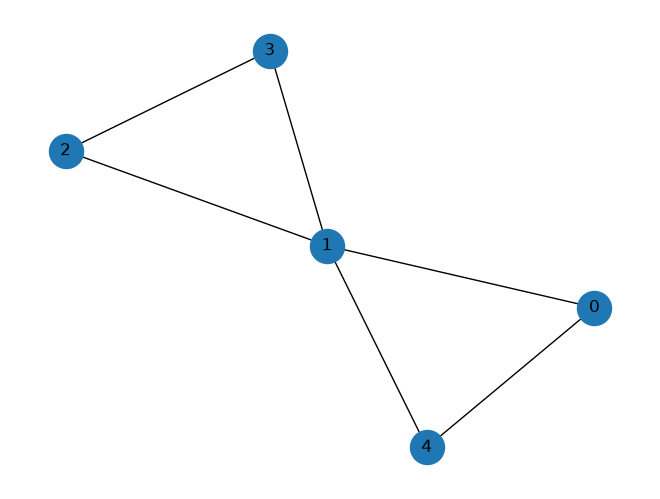

In [5]:
n = 5
graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1))

edge_list = [
    (2, 3, 1.0),
    (0, 4, 1.0),
    (1, 0, 1.0),
    (1, 2, 1.0),
    (1, 3, 1.0),
    (1, 4, 1.0),
]
graph.add_edges_from(edge_list)
mpl_draw(graph, node_size=600, with_labels=True)

In [6]:
from qiskit.quantum_info import SparsePauliOp

def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list."""
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list

max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, n)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IZZII', 'ZIIIZ', 'IIIZZ', 'IIZZI', 'IZIZI', 'ZIIZI'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


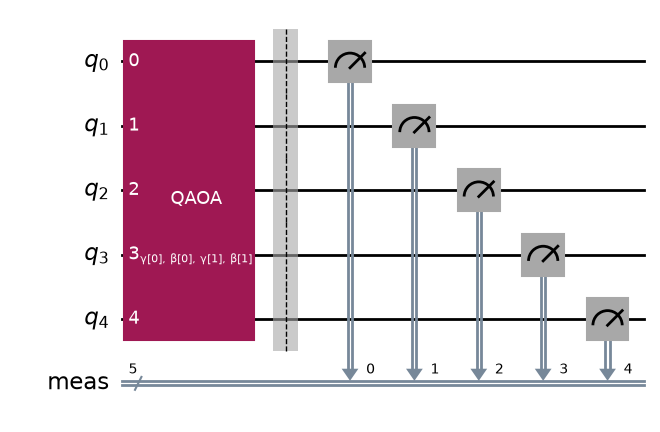

In [7]:
from qiskit.circuit.library import QAOAAnsatz

circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()

circuit.draw('mpl')

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Load the default service and find a suitable backend
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=127
)
print("Selected backend:", backend)

Selected backend: <IBMBackend('ibm_marrakesh')>


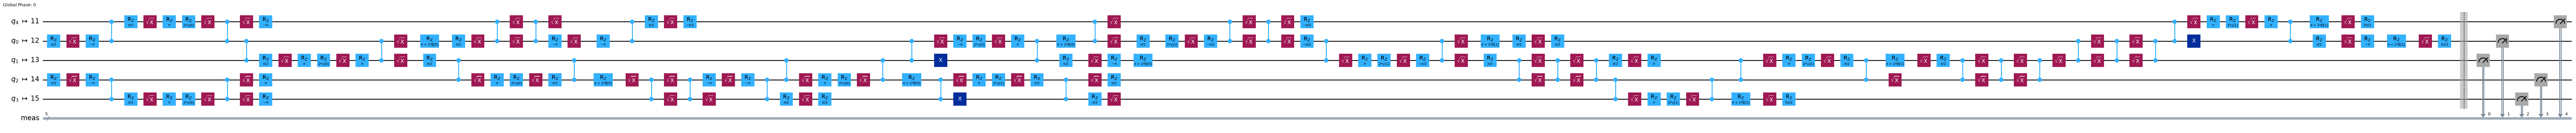

In [16]:
# Transpile the circuit for the selected backend
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
candidate_circuit = pm.run(circuit)

# Visualize the transpiled circuit
candidate_circuit.draw('mpl', fold=False, idle_wires=False)

In [17]:
import numpy as np

initial_gamma = np.pi
initial_beta = np.pi / 2

# For reps=2 (2 layers), we need 2 gammas and 2 betas
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]

In [18]:
objective_func_vals = []  # Global variable for tracking optimizer progress

def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # Map observable to physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])
    
    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

In [19]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Estimator, Session
from scipy.optimize import minimize
import matplotlib.pyplot as plt

simulator = AerSimulator()

with Session(backend=simulator) as session:
    # For qiskit-ibm-runtime >=0.24.0 use mode=, otherwise use session=
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    # Error mitigation configuration
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    # Run optimizer
    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.9560439560439562
       x: [ 2.096e+00  2.157e+00  3.359e+00  3.009e+00]
    nfev: 28
   maxcv: 0.0


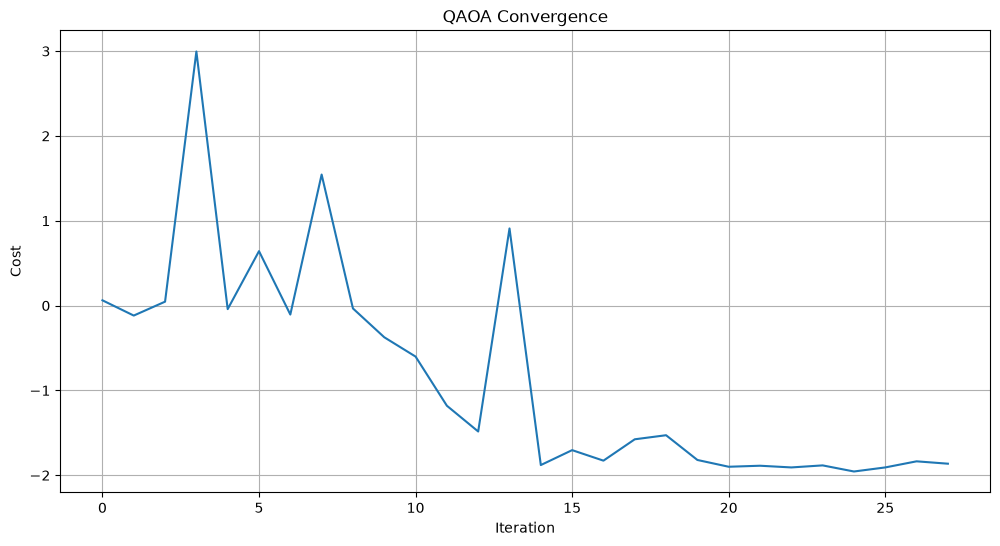

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("QAOA Convergence")
plt.grid(True)
plt.show()

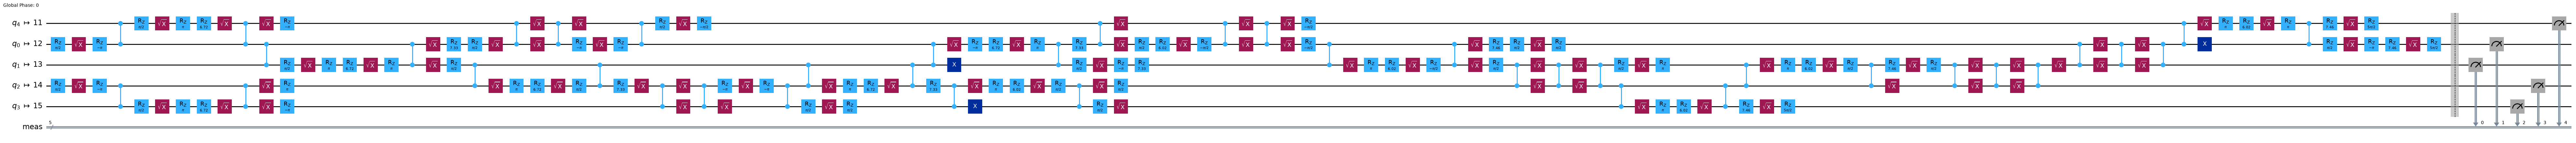

In [21]:
# from here i start referencing IBM docs for Qiskit
optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw("mpl", fold=False, idle_wires=False)

In [22]:
from qiskit_ibm_runtime import Sampler

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=simulator)
sampler.options.default_shots = 10000

pub = (optimized_circuit,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
print(final_distribution_int)

{28: 0.0584, 5: 0.0525, 10: 0.0547, 26: 0.0587, 9: 0.0575, 13: 0.0566, 21: 0.0559, 22: 0.0558, 25: 0.0566, 2: 0.0434, 24: 0.0584, 6: 0.0548, 29: 0.0449, 7: 0.0564, 18: 0.0519, 20: 0.0577, 3: 0.0505, 11: 0.0558, 31: 0.0046, 14: 0.0022, 19: 0.0019, 17: 0.0036, 0: 0.0048, 12: 0.0023, 4: 0.0001}


In [24]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]


keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 1, 0, 1, 1]


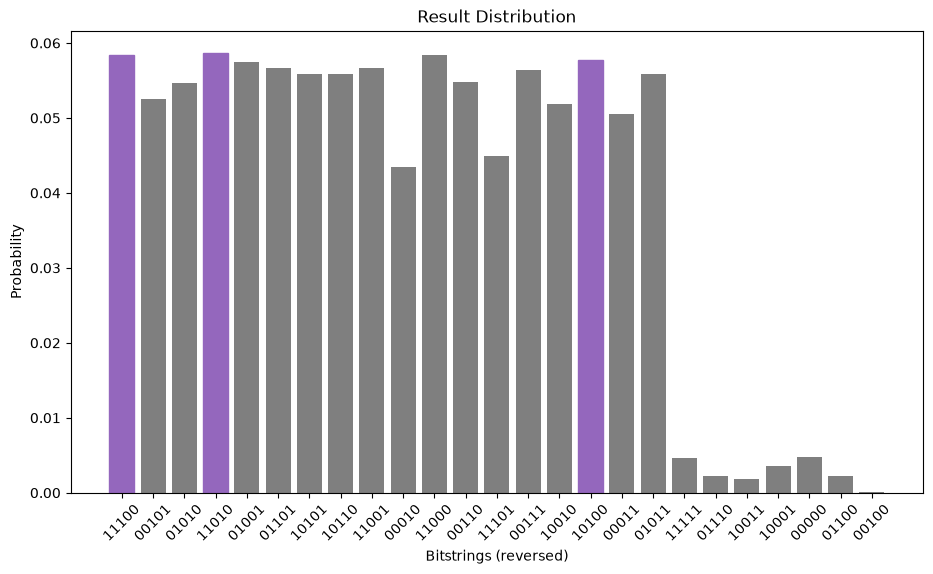

In [26]:
plt.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p[0])].set_color("tab:purple")
plt.show()

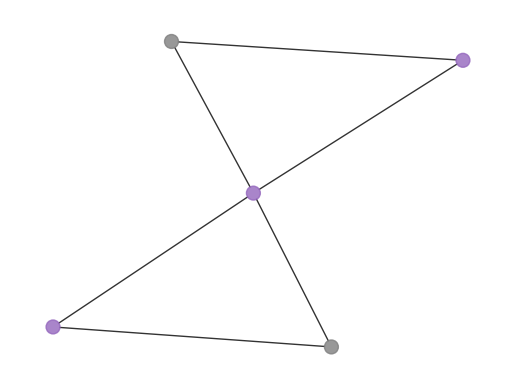

In [28]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(
        G, node_color=colors, node_size=100, alpha=0.8, pos=pos
    )


plot_result(graph, most_likely_bitstring)